In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from neural_network.trainer import TwoDimensionalTrainer
from neural_network.config import MarketParams, ModelConfig
from neural_network.payoff import PutMaxTwoAssets, PutMinTwoAssets, PutProductTwoAssets

In [2]:
S0 = 1.0
r = 0.1
sigma = {'sigma1': 0.4, 'sigma2': 0.4, 'rho': 0.3}
K = 1.0
T = 1.0
S_min = 0.0
S_max = 3 * K

market_params = MarketParams(S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [3]:
input_size = 3
hidden_sizes = [32, 64, 32]
output_size = 1
activation = nn.ReLU()
learning_rate = 0.001
model_config = ModelConfig(
    input_size=input_size,
    hidden_sizes=hidden_sizes,
    output_size=output_size,
    activation=activation,
    learning_rate=learning_rate
)

In [4]:
put_max = PutMaxTwoAssets()
trainer_max = TwoDimensionalTrainer(model_config, market_params, put_max, 67)
trainer_max.train(num_samples=1000, max_iterations=10000, tol=1e-6)

Iteration 0, Loss: 1.0020194053649902
Iteration 100, Loss: 0.007231550291180611
Iteration 200, Loss: 0.003065922763198614
Converged at iteration 259


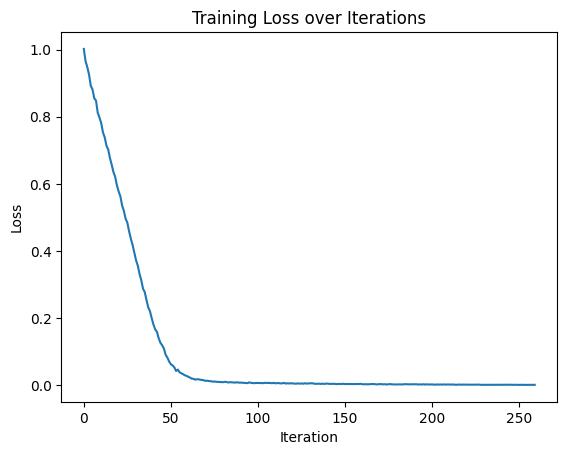

In [5]:
trainer_max.plot_losses()

In [6]:
trainer_max.predict(0, 1, 1).item()

0.006848037242889404

In [7]:
put_min = PutMinTwoAssets()
trainer_min = TwoDimensionalTrainer(model_config, market_params, put_min, 67)
trainer_min.train(num_samples=1000, max_iterations=10000, tol=1e-6)

Iteration 0, Loss: 2.366415500640869
Iteration 100, Loss: 0.024919543415308
Iteration 200, Loss: 0.004938407801091671
Iteration 300, Loss: 0.0028498549945652485
Converged at iteration 387


In [8]:
trainer_min.predict(0, 1, 1).item()

0.04816029965877533

In [9]:
S0 = 5.0
r = 0.1
sigma = {'sigma1': 0.4, 'sigma2': 0.4, 'rho': 0.3}
K = 25.0
T = 1.0
S_min = 0.0
S_max = np.sqrt(3 * K)

market_params = MarketParams(S0=S0, r=r, sigma=sigma, K=K, T=T, S_min=S_min, S_max=S_max)

In [13]:
put_product = PutProductTwoAssets()
trainer_product = TwoDimensionalTrainer(model_config, market_params, put_product, 67)
trainer_product.train(num_samples=1000, max_iterations=10000, tol=1e-4)

Iteration 0, Loss: 1233.4716796875
Iteration 100, Loss: 253.44766235351562
Iteration 200, Loss: 18.99490737915039
Iteration 300, Loss: 7.720548152923584
Iteration 400, Loss: 4.017724990844727
Iteration 500, Loss: 2.1873435974121094
Iteration 600, Loss: 1.442049264907837
Iteration 700, Loss: 1.054593801498413
Converged at iteration 777


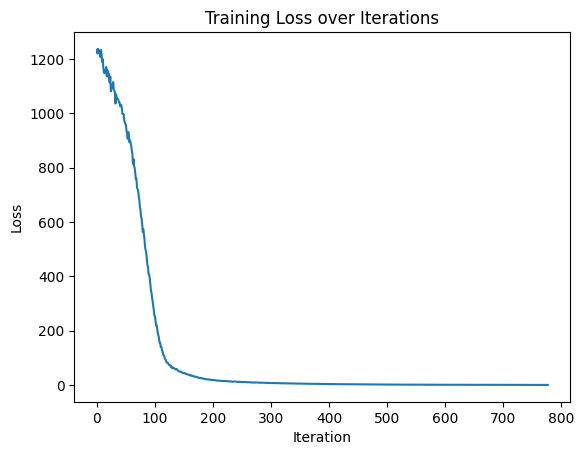

In [14]:
trainer_product.plot_losses()

In [17]:
trainer_product.predict(1, 5, 5).item()

1.1337330341339111